# IMPORT LIBRARY

In [4]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# CONNECTING TO DATABASE

In [5]:
load_dotenv("../.env")

conn = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

print("Connection created")

Connection created


# PROPERTY PRICE DRIVERS & PREDICTIVE MODELING

##
RETRIVE DATA

In [6]:
dataset = '''SELECT
                t.property_id
                ,t.deal_status
                ,t.deal_price
                ,t.deal_date
                ,t.payment_mode
                ,t.city
                ,l.listed_price
                ,l.days_on_market
                ,p.property_type
                ,p.size_sqm
                ,p.has_parking
                ,p.near_transit
                ,p.near_school
                ,p.year_built
            FROM transactions t
            LEFT JOIN listings l ON t.listing_id = l.listing_id
            LEFT JOIN properties p ON t.property_id = p.property_id
            WHERE DATE_PART('year',deal_date)<=2024
            '''
df_dataset = pd.read_sql(dataset,conn)
len(df_dataset)

3776

##
LOAD DATA AND DATA PREPARATION

In [7]:
df_completed = df_dataset[df_dataset['deal_status']=='Completed']

print(df_completed.isna().sum())
print(f'\nNumber of Duplicate : {df_completed.duplicated().sum()}')

bool_cols = ['has_parking', 'near_transit', 'near_school']
for col in bool_cols:
    df_completed[col] = df_completed[col].astype(str).str.strip().str.lower()=='true'

property_id       0
deal_status       0
deal_price        0
deal_date         0
payment_mode      0
city              0
listed_price      0
days_on_market    0
property_type     0
size_sqm          0
has_parking       0
near_transit      0
near_school       0
year_built        0
dtype: int64

Number of Duplicate : 0


> FEATURE ENGINEERING

In [8]:
df_completed['deal_date'] =(\
    pd.to_datetime(df_completed['deal_date'])
)

df_completed['year_deal'] = (\
    df_completed['deal_date']
    .dt.year
)

df_completed['month_deal'] = (\
    df_completed['deal_date']
    .dt.month
)

df_completed['property_age'] = (\
    (df_completed['deal_date'].dt.year)-
    df_completed['year_built']
)

> CHECKING OUTLIER

In [9]:
columns = ['deal_price','listed_price','size_sqm'
,'days_on_market','property_age']

for col in columns:
    Q1 = df_completed[col].quantile(0.25)
    Q3 = df_completed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers =(\
        df_completed[(df_completed[col] < lower_bound) | 
        (df_completed[col] > upper_bound)]
    )
    print(f"Outlier pada '{col}': {len(outliers)} baris ({len(outliers)/len(df_completed)*100:.1f}%)")

Outlier pada 'deal_price': 182 baris (4.9%)
Outlier pada 'listed_price': 190 baris (5.1%)
Outlier pada 'size_sqm': 188 baris (5.0%)
Outlier pada 'days_on_market': 19 baris (0.5%)
Outlier pada 'property_age': 8 baris (0.2%)


> CORRELATION

deal_price        1.000000
listed_price      0.996936
size_sqm          0.529463
days_on_market    0.060027
property_age      0.022697


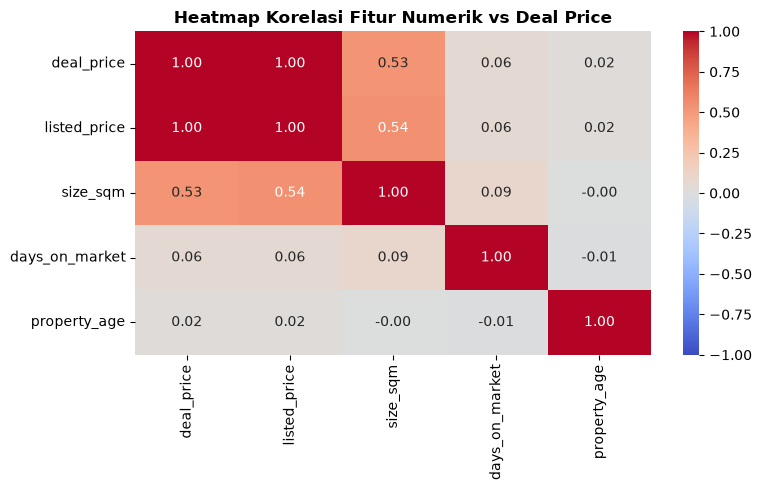

In [10]:
corr_matrix = (\
    df_completed[['deal_price','listed_price','size_sqm'
                ,'days_on_market','property_age']].corr()
)

print(corr_matrix['deal_price'].sort_values(ascending=False).to_string())
plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Fitur Numerik vs Deal Price', fontweight='bold')
plt.tight_layout()
plt.show()

> FEATURE SELECTION

In [20]:
df_completed.columns

Index(['property_id', 'deal_status', 'deal_price', 'deal_date', 'payment_mode',
       'city', 'listed_price', 'days_on_market', 'property_type', 'size_sqm',
       'has_parking', 'near_transit', 'near_school', 'year_built', 'year_deal',
       'month_deal', 'property_age'],
      dtype='str')

In [22]:
features_cols = ['payment_mode','city', 'days_on_market', 
                'property_type', 'size_sqm','has_parking', 'near_transit',
                'near_school','property_age','year_deal','month_deal']

target_col = 'deal_price'

x = df_completed[features_cols].copy()
y = df_completed[target_col].copy()

x.info()

<class 'pandas.DataFrame'>
Index: 3737 entries, 0 to 3775
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   payment_mode    3737 non-null   str    
 1   city            3737 non-null   str    
 2   days_on_market  3737 non-null   int64  
 3   property_type   3737 non-null   str    
 4   size_sqm        3737 non-null   float64
 5   has_parking     3737 non-null   bool   
 6   near_transit    3737 non-null   bool   
 7   near_school     3737 non-null   bool   
 8   property_age    3737 non-null   int64  
 9   year_deal       3737 non-null   int32  
 10  month_deal      3737 non-null   int32  
dtypes: bool(3), float64(1), int32(2), int64(2), str(3)
memory usage: 244.5 KB


>ENCODING

In [24]:
cat_cols = ['payment_mode', 'city', 'property_type','month_deal','year_deal']

x_encoded = pd.get_dummies(x, columns = cat_cols,drop_first = True)

x_encoded

,days_on_market,size_sqm,has_parking,near_transit,near_school,property_age,payment_mode_Installment,payment_mode_Mortgage,payment_mode_Unknown,city_Chattogram,...,month_deal_5,month_deal_6,month_deal_7,month_deal_8,month_deal_9,month_deal_10,month_deal_11,month_deal_12,year_deal_2023,year_deal_2024
0,19,108.5,False,True,False,4,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
1,49,253.4,False,True,False,5,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
2,56,65.5,True,False,False,12,True,False,False,False,...,False,False,False,False,False,True,False,False,False,True
3,39,131.1,True,True,False,19,False,False,False,True,...,False,False,False,False,False,False,True,False,True,False
4,29,243.5,True,False,False,16,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3771,55,145.9,False,True,True,12,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
3772,53,119.4,True,False,False,4,False,True,False,False,...,False,True,False,False,False,False,False,False,False,False
3773,56,256.9,True,True,True,7,False,False,True,False,...,False,False,True,False,False,False,False,False,False,False
3774,98,282.3,False,False,True,13,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True


>SPLIT TRAIN-TEST

In [25]:
x_train, x_test, y_train, y_test =(
    train_test_split(
    x_encoded, 
    y, 
    test_size = 0.2, 
    random_state = 42
    )
)

print(f"\nData Train: {x_train.shape[0]} baris | Data Test: {x_test.shape[0]} baris")


Data Train: 2989 baris | Data Test: 748 baris


>> identifying baseline categories

In [26]:

encoded_columns = ['payment_mode', 'city', 'property_type', 'month_deal', 'year_deal']


print("----IDENTIFYING BASELINE CATEGORIES (REFERENCE GROUPS)----")


for col in encoded_columns:
    all_categories = set(df_completed[col].astype(str).unique())
    prefix = f"{col}_"
    categories_in_model = set([
        str(feature).replace(prefix, '') 
        for feature in x_train.columns 
        if str(feature).startswith(prefix)
    ])
    baseline = all_categories - categories_in_model

    baseline_value = list(baseline)[0] if baseline else "None (All categories are present)"
    print(f"• Baseline for '{col}' : {baseline_value}")



----IDENTIFYING BASELINE CATEGORIES (REFERENCE GROUPS)----
• Baseline for 'payment_mode' : Cash
• Baseline for 'city' : Barishal
• Baseline for 'property_type' : Apartment
• Baseline for 'month_deal' : 1
• Baseline for 'year_deal' : 2022


# MODELLING

## LINEAR REGRESSION

In [27]:

x_train_lr = x_train.copy()
x_test_lr = x_test.copy()


y_train_lr = np.log1p(y_train)
y_test_lr = np.log1p(y_test)


x_train_lr['size_sqm'] = np.log1p(x_train_lr['size_sqm'])
x_test_lr['size_sqm'] = np.log1p(x_test_lr['size_sqm'])


num_cols = ['days_on_market', 'size_sqm', 'property_age']


x_train_lr_scaled = x_train_lr.copy()
x_test_lr_scaled = x_test_lr.copy()

scaler = StandardScaler()
x_train_lr_scaled[num_cols] = scaler.fit_transform(x_train_lr[num_cols])
x_test_lr_scaled[num_cols] = scaler.transform(x_test_lr[num_cols])


lr_model = LinearRegression()
lr_model.fit(x_train_lr_scaled, y_train_lr)

y_pred_lr_log = lr_model.predict(x_test_lr_scaled)


y_pred_lr = np.expm1(y_pred_lr_log)
y_test_actual_lr = np.expm1(y_test_lr)


mae_lr = mean_absolute_error(y_test_actual_lr, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test_actual_lr, y_pred_lr))
r2_lr = r2_score(y_test_actual_lr, y_pred_lr)

print(f"\n--- Linear Regression Result---")
print(f"MAE  : BDT {mae_lr:,.0f}")
print(f"RMSE : BDT {rmse_lr:,.0f}")
print(f"R2   : {r2_lr:.4f} ({r2_lr*100:.2f}%)")


--- Linear Regression Result---
MAE  : BDT 2,555,648
RMSE : BDT 3,545,891
R2   : 0.7662 (76.62%)


In [28]:
feature_names = x_train_lr.columns

coef_lr = lr_model.coef_


df_coef = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient Value (b)': coef_lr
}).sort_values(by='Coefficient Value (b)', key=abs, ascending=False).reset_index(drop = True)


print(f"Intercept Values (Konstanta a) : {lr_model.intercept_:.4f}\n")

print("--- Coefficient Fitures ---")
df_coef

Intercept Values (Konstanta a) : 15.8519

--- Coefficient Fitures ---


,Feature,Coefficient Value (b)
0,city_Dhaka,0.679373
1,property_type_Commercial,0.625711
2,city_Chattogram,0.430817
3,property_type_House,0.364589
4,size_sqm,0.221070
5,city_Sylhet,0.218636
6,property_type_Land,-0.144071
7,city_Khulna,0.109592
8,city_Mymensingh,0.075752
9,city_Rajshahi,0.070774


## RANDOM FOREST

In [29]:
x_train_rf = x_train.copy()
x_test_rf  = x_test.copy()

y_train_rf = np.log1p(y_train)
y_test_rf  = np.log1p(y_test)


rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train_rf, y_train_rf)


y_pred_rf_log = rf_model.predict(x_test_rf)

y_pred_rf_actual   = np.expm1(y_pred_rf_log)
y_test_rf_actual   = np.expm1(y_test_rf)


mae_rf  = mean_absolute_error(y_test_rf_actual, y_pred_rf_actual)
rmse_rf = np.sqrt(mean_squared_error(y_test_rf_actual, y_pred_rf_actual))
r2_rf   = r2_score(y_test_rf_actual, y_pred_rf_actual)

# 6. Print Hasil
print(f"\n---- Random Forest Results ----")
print(f"MAE  : BDT {mae_rf:,.0f}")
print(f"RMSE : BDT {rmse_rf:,.0f}")
print(f"R2   : {r2_rf:.4f} ({r2_rf*100:.2f}%)")


---- Random Forest Results ----
MAE  : BDT 2,481,512
RMSE : BDT 3,517,241
R2   : 0.7699 (76.99%)


In [18]:
contribution = rf_model.feature_importances_

feature_names = x_train_rf.columns

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Contribution (%)': contribution * 100
}).sort_values(by='Contribution (%)', ascending=False).reset_index(drop= True)

print("------Random Forest Contribution Feature------")
#df_importance 

------Random Forest Contribution Feature------


C:\Users\HP\AppData\Local\Temp\ipykernel_5288\3568295664.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


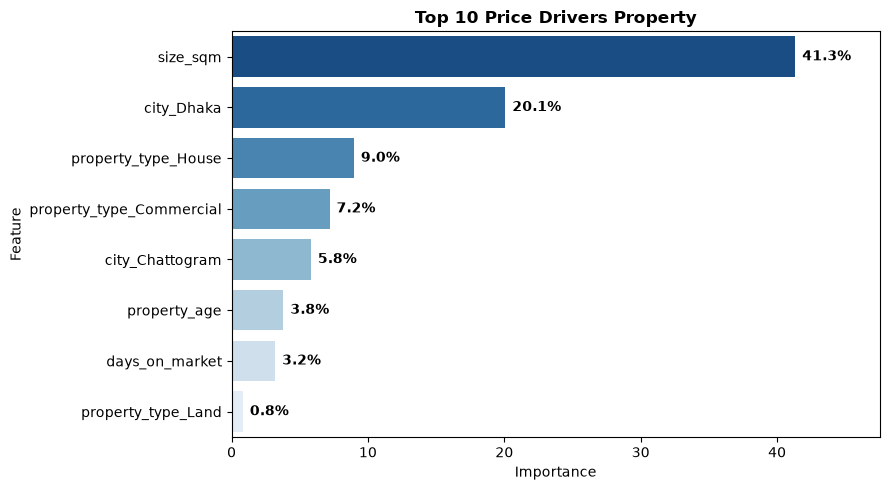

In [30]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=df_importance.head(8), 
    x='Contribution (%)', 
    y='Feature', 
    palette='Blues_r'
)
    
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.1f}%',
                (width + 0.5, p.get_y() + p.get_height() / 2.),
                ha='left', 
                va='center', 
                fontsize=10, 
                fontweight='bold',
                color='black')
    
plt.title('Top 10 Price Drivers Property', fontweight='bold')
plt.xlabel('Importance')
plt.xlim(0, max(df_importance['Contribution (%)']) * 1.15)
plt.tight_layout()
plt.show()